In [155]:
import cv2 as cv
import numpy as np 
import matplotlib.pyplot as plt 
import time
import pytesseract as pyt
import re
import json

In [156]:
def extract_roi(src):
    image=cv.imread(src)
    if image is None:
        print('Image not loaded')
    
    gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
    
    H,W=gray.shape

    contour=cv.findContours(gray,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)[0]
    boxes=[cv.boundingRect(c) for c in contour if cv.boundingRect(c)[0]>W*0.35]

    min_x=min(b[0] for b in boxes)-25
    min_y=min(b[1] for b in boxes)-25
    max_x=max(b[0]+b[2] for b in boxes)+25
    max_y=max(b[1]+b[3] for b in boxes)+25

    roi=image[min_y:max_y,min_x:max_x]
    return roi,image

In [157]:
def extract_green_roi(src):
    image=cv.imread(src)
    if image is None:
        print('Image not loaded')

    hsv=cv.cvtColor(image,cv.COLOR_BGR2HSV)

    lower_green=np.array([35,50,50])
    upper_green=np.array([85,255,255])

    mask=cv.inRange(hsv,lower_green,upper_green)

    kernel=cv.getStructuringElement(cv.MORPH_RECT,(5,5))
    mask=cv.morphologyEx(mask,cv.MORPH_CLOSE,kernel)

    contours,_=cv.findContours(mask,cv.RETR_EXTERNAL,cv.CHAIN_APPROX_SIMPLE)

    if not contours:
        print('No green region founded')
        return image

    larget_contour=max(contours,key=cv.contourArea)
    x,y,w,h=cv.boundingRect(larget_contour)

    roi=image[y:y+h,x:x+w]
    return roi,image


In [158]:
def process_img(roi):
    gray=cv.cvtColor(roi,cv.COLOR_BGR2GRAY)
    resized = cv.resize(gray, None, fx=2.0, fy=2.0, interpolation=cv.INTER_CUBIC)

    guess=cv.GaussianBlur(resized,(5,5),0)
    thresh=cv.threshold(guess,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)[1]

    kernel=cv.getStructuringElement(cv.MORPH_RECT,(3,3))
    dilate=cv.dilate(thresh,kernel,iterations=3)

    final_processed=cv.bitwise_not(dilate)

    return final_processed

In [159]:
def read_and_validate(image):
    start_time=time.perf_counter()

    custom_config = r'--psm 4 -c tessedit_char_whitelist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789/."'

    data=pyt.image_to_data(image,config=custom_config,output_type=pyt.Output.DICT)

    lines_dict={}
    print(len(data['text']))

    for i in range (len(data['text'])):
        word=data['text'][i].strip()
        conf=int(data['conf'][i])
        line_key = (data['block_num'][i], data['par_num'][i], data['line_num'][i])

        if word and conf != -1:
            if line_key not in lines_dict:
                lines_dict[line_key] = {
                    'text': [],
                    'conf': []
                }
            lines_dict[line_key]['text'].append(word)
            lines_dict[line_key]['conf'].append(conf)
    
    extracted_line=[]
    full_text_list=[]

    for content in lines_dict.values():
        line_text = " ".join(content['text'])
        line_conf = sum(content['conf']) / len(content['conf']) if content['conf'] else 0
        
        extracted_line.append({
            'text': line_text,
            'confidence': round(line_conf, 2)
        })
        
        full_text_list.append(line_text)
    full_text='\n'.join(full_text_list)

    batch_pattern = r'R[0-9O/]{1,2}\d{5,}'
    date_pattern=r'\d{2}/\d{4}|\d{2}/\d{2}/\d{4}'
    batch_match=re.search(batch_pattern,full_text)
    dates_found=re.findall(date_pattern,full_text)

    validity={
            'is_batch_valid':bool(batch_match),
            'detected_batch':batch_match.group() if batch_match else None,
            'are_dates_valid':len(dates_found)>=2,
            'detected_dates':dates_found
        }

    end_time=time.perf_counter()
    processing_time=round(end_time-start_time,2)*1000
        
    final_output={
            'raw_text':full_text,
            'line_details':extracted_line,
            'validation':validity,
            'processing_time':processing_time
        }

    return json.dumps(final_output,indent=4)

In [160]:
def detect_text(src):
    roi,image=extract_green_roi(src)
    processed_image=process_img(roi)
    result=read_and_validate(processed_image)

    plt.figure(figsize=(6,4))
    plt.subplot(2,2,1)
    plt.title('Orignal image')
    plt.imshow(cv.cvtColor(image,cv.COLOR_BGR2RGB))

    plt.subplot(2,2,2)
    plt.title('ROI image')
    plt.imshow(cv.cvtColor(roi,cv.COLOR_BGR2RGB))

    plt.subplot(2,2,3)
    plt.title('Processed image')
    plt.imshow(cv.cvtColor(processed_image,cv.COLOR_BGR2RGB))

    plt.tight_layout()
    print(result)


25
{
    "raw_text": "RO/\n60619\nOOS\n300642025\nT1Z\n.O",
    "line_details": [
        {
            "text": "RO/",
            "confidence": 0.0
        },
        {
            "text": "60619",
            "confidence": 0.0
        },
        {
            "text": "OOS",
            "confidence": 0.0
        },
        {
            "text": "300642025",
            "confidence": 0.0
        },
        {
            "text": "T1Z",
            "confidence": 0.0
        },
        {
            "text": ".O",
            "confidence": 0.0
        }
    ],
    "validation": {
        "is_batch_valid": false,
        "detected_batch": null,
        "are_dates_valid": false,
        "detected_dates": []
    },
    "processing_time": 1040.0
}


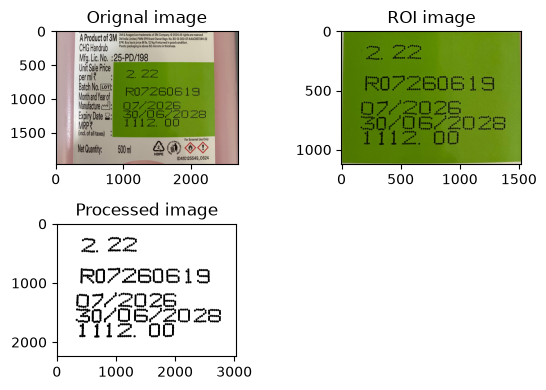

In [161]:
detect_text('../image/real_images/WhatsApp Image 2026-07-16 at 19.11.01.jpeg')

16
{
    "raw_text": ". P\nPOYSE0S0S\n2\n2006202\nPE4",
    "line_details": [
        {
            "text": ". P",
            "confidence": 0.0
        },
        {
            "text": "POYSE0S0S",
            "confidence": 0.0
        },
        {
            "text": "2",
            "confidence": 2.0
        },
        {
            "text": "2006202",
            "confidence": 43.0
        },
        {
            "text": "PE4",
            "confidence": 0.0
        }
    ],
    "validation": {
        "is_batch_valid": false,
        "detected_batch": null,
        "are_dates_valid": false,
        "detected_dates": []
    },
    "processing_time": 670.0
}


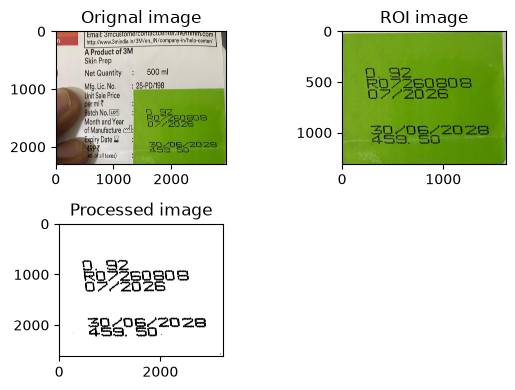

In [162]:
detect_text('../image/real_images/WhatsApp Image 2026-07-16 at 19.11.02 (2).jpeg')

25
{
    "raw_text": "RO/\n60619\nOOS\n300642025\nT1Z\n.O",
    "line_details": [
        {
            "text": "RO/",
            "confidence": 0.0
        },
        {
            "text": "60619",
            "confidence": 0.0
        },
        {
            "text": "OOS",
            "confidence": 0.0
        },
        {
            "text": "300642025",
            "confidence": 0.0
        },
        {
            "text": "T1Z",
            "confidence": 0.0
        },
        {
            "text": ".O",
            "confidence": 0.0
        }
    ],
    "validation": {
        "is_batch_valid": false,
        "detected_batch": null,
        "are_dates_valid": false,
        "detected_dates": []
    },
    "processing_time": 690.0
}


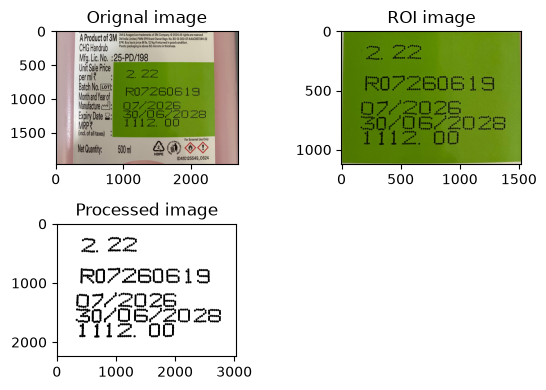

In [163]:
detect_text('../image/real_images/WhatsApp Image 2026-07-16 at 19.11.01.jpeg')

image type2 

In [164]:
def detect_text(src):
    roi,image=extract_roi(src)
    processed_image=process_img(roi)
    result=read_and_validate(processed_image)

    plt.figure(figsize=(6,4))
    plt.subplot(2,2,1)
    plt.title('Orignal image')
    plt.imshow(cv.cvtColor(image,cv.COLOR_BGR2RGB))

    plt.subplot(2,2,2)
    plt.title('ROI image')
    plt.imshow(cv.cvtColor(roi,cv.COLOR_BGR2RGB))

    plt.subplot(2,2,3)
    plt.title('Processed image')
    plt.imshow(cv.cvtColor(processed_image,cv.COLOR_BGR2RGB))

    plt.tight_layout()
    print(result)

15
{
    "raw_text": "306.00\nRO260911\n07/2026\n30/06/2029\n15300.00",
    "line_details": [
        {
            "text": "306.00",
            "confidence": 0.0
        },
        {
            "text": "RO260911",
            "confidence": 0.0
        },
        {
            "text": "07/2026",
            "confidence": 72.0
        },
        {
            "text": "30/06/2029",
            "confidence": 91.0
        },
        {
            "text": "15300.00",
            "confidence": 0.0
        }
    ],
    "validation": {
        "is_batch_valid": true,
        "detected_batch": "RO260911",
        "are_dates_valid": true,
        "detected_dates": [
            "07/2026",
            "30/06/2029"
        ]
    },
    "processing_time": 400.0
}


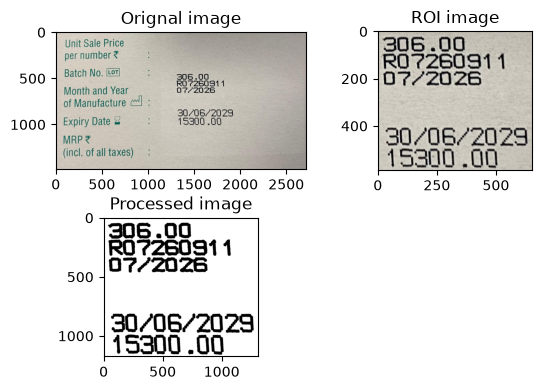

In [165]:
detect_text('../image/real_images/WhatsApp Image 2026-07-16 at 19.11.05 (3).jpeg')

In [ ]:
detect_text('../image/real_images/WhatsApp Image 2026-07-16 at 19.11.04 (3).jpeg')

15
{
    "raw_text": "450.50\n608451234\n11/2025\n31/10/2028\n22200.00",
    "line_details": [
        {
            "text": "450.50",
            "confidence": 0.0
        },
        {
            "text": "608451234",
            "confidence": 0.0
        },
        {
            "text": "11/2025",
            "confidence": 56.0
        },
        {
            "text": "31/10/2028",
            "confidence": 46.0
        },
        {
            "text": "22200.00",
            "confidence": 0.0
        }
    ],
    "validation": {
        "is_batch_valid": false,
        "detected_batch": null,
        "are_dates_valid": true,
        "detected_dates": [
            "11/2025",
            "31/10/2028"
        ]
    },
    "processing_time": 250.0
}


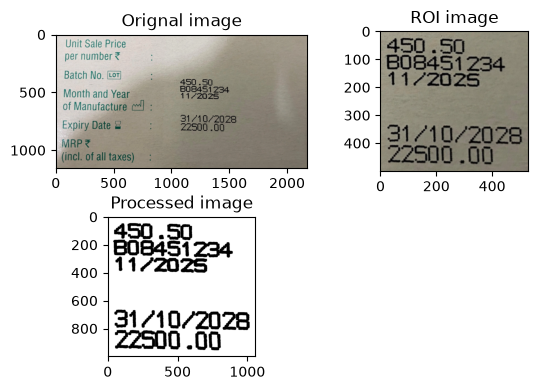

In [ ]:
detect_text('../image/real_images/dot-print1.png')